# CFD CLIP Feature Retrieval Test

This notebook tests how accurately CLIP's image-text shared semantic space retrieves CFD faces as facial-feature descriptions become more specific.

Design logic:

1. Start with a general face-photo prompt.
2. Add feature categories step by step in the order motivated by your feature-frequency estimates.
3. At every step, retrieve the top-k CFD images and evaluate whether the true target is retrieved.
4. Separately test feature consistency: when a feature is added, do the retrieved faces share the target's feature label?

Important limitation: CFD does not directly annotate every feature category in your list. For unsupported categories, this notebook records them in the ladder but does not add a phrase unless an annotation is available.

## 0. Setup

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import json
import math
import sys

import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "src" / "pyWitnessAI").exists() else cwd.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

OUT = ROOT / "build" / "study3_cfd_clip_pilot_outputs"
FEATURE_OUT = OUT / "feature_ladder"
FEATURE_OUT.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("OUT:", OUT)
print("FEATURE_OUT:", FEATURE_OUT)

ROOT: D:\PhD\Software\pyWitnessAI
OUT: D:\PhD\Software\pyWitnessAI\build\study3_cfd_clip_pilot_outputs
FEATURE_OUT: D:\PhD\Software\pyWitnessAI\build\study3_cfd_clip_pilot_outputs\feature_ladder


In [2]:
from pyWitnessAI.cfd_clip_pilot import ClipIndex, build_cfd_manifest, evaluate_retrieval
from pyWitnessAI.cfd_clip_pilot.clip_backend import SentenceTransformerClipEncoder
from pyWitnessAI.cfd_clip_pilot.visualization import show_clip_lineup

CFD_IMAGE_DIR = ROOT / "data" / "CFD Version 3.0" / "Images"
CFD_METADATA_PATH = ROOT / "data" / "CFD Version 3.0" / "CFD 3.0 Norming Data and Codebook.xlsx"

MODEL_NAME = "clip-ViT-B-32"
DEVICE = "cpu"  # Change to "cuda" if your PyTorch install supports CUDA.
TOP_K = 50
BATCH_SIZE = 32
MAX_QUERIES = None  # Set to an integer, e.g. 100, for a faster smoke run.

print("CFD image dir exists:", CFD_IMAGE_DIR.exists())
print("CFD metadata exists:", CFD_METADATA_PATH.exists())

E:\Conda\envs\pwai\Lib\site-packages\mtcnn\mtcnn.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


CFD image dir exists: True
CFD metadata exists: True


## 1. Load Manifest And CLIP Index

In [3]:
manifest_path = OUT / "manifest.csv"
if manifest_path.exists():
    manifest = pd.read_csv(manifest_path)
else:
    manifest = build_cfd_manifest(
        image_dir=CFD_IMAGE_DIR,
        metadata_path=CFD_METADATA_PATH,
        neutral_only=True,
    )
    manifest.to_csv(manifest_path, index=False)

manifest = manifest.drop_duplicates("target_id", keep="first").reset_index(drop=True)
if MAX_QUERIES is not None:
    manifest = manifest.sample(n=min(MAX_QUERIES, len(manifest)), random_state=2026).reset_index(drop=True)

print("manifest shape:", manifest.shape)
manifest[["image_id", "target_id", "gender", "race", "age", "image_path"]].head()

manifest shape: (827, 161)


,image_id,target_id,gender,race,age,image_path
0,CFD-AF-200-228-N,AF-200,female,Asian,32.5714285714286,D:\PhD\Software\pyWitnessAI\data\CFD Version 3...
1,CFD-AF-201-060-N,AF-201,female,Asian,23.6666666666667,D:\PhD\Software\pyWitnessAI\data\CFD Version 3...
2,CFD-AF-202-122-N,AF-202,female,Asian,24.448275862069,D:\PhD\Software\pyWitnessAI\data\CFD Version 3...
3,CFD-AF-203-077-N,AF-203,female,Asian,22.7586206896552,D:\PhD\Software\pyWitnessAI\data\CFD Version 3...
4,CFD-AF-204-067-N,AF-204,female,Asian,30.1379310344828,D:\PhD\Software\pyWitnessAI\data\CFD Version 3...


In [4]:
encoder = SentenceTransformerClipEncoder(model_name=MODEL_NAME, device=DEVICE)

index_dir = OUT / "clip_index"
if not (index_dir / "image_embeddings.npy").exists():
    raise FileNotFoundError(
        f"CLIP index not found: {index_dir}. Build it first with 03_build_clip_index.py or the pilot notebook."
    )

clip_index = ClipIndex.load(index_dir)
print("index images:", len(clip_index.manifest))
clip_index.metadata

index images: 831


{'embedding_dim': 512,
 'embedding_sha256': '942677295a08c51c19e47565d431e94c47e5be8d82f700142df853ae84796dea',
 'image_count': 831,
 'model_name': 'clip-ViT-B-32'}

## 2. Feature Order And CFD Support

The feature order below follows your current estimates. The percentages are stored as metadata for reporting; they do not weight the CLIP retrieval scores.

In [5]:
FEATURE_ORDER = [
    ("gender", 98.0),
    ("hair", 89.9),
    ("facial_hair", 83.8),
    ("clothes", 81.8),
    ("eyes", 41.4),
    ("eyebrows", 15.2),
    ("nose", 14.1),
    ("build", 12.1),
    ("face_shape", 9.1),
    ("race", 6.1),
    ("forehead", 6.1),
    ("mouth", 5.1),
    ("ears", 3.0),
    ("jaw", 2.0),
    ("teeth", 0.0),
]

feature_order_df = pd.DataFrame(FEATURE_ORDER, columns=["feature", "frequency_percent"])
feature_order_df

,feature,frequency_percent
0,gender,98.0
1,hair,89.9
2,facial_hair,83.8
3,clothes,81.8
4,eyes,41.4
5,eyebrows,15.2
6,nose,14.1
7,build,12.1
8,face_shape,9.1
9,race,6.1


## 3. Feature Descriptor Functions

For metadata-supported features, the notebook converts CFD annotations or measurements into natural-language phrases. Numeric measurements are converted into quantile labels such as `narrow nose`, `broad nose`, `full lips`, or `thin eyebrows`.

Unsupported categories are explicitly marked as unsupported rather than silently invented.

In [6]:
@dataclass(frozen=True)
class FeaturePhrase:
    feature: str
    phrase: str
    label: str
    slot: str = "detail"  # "subject" or "detail"


def clean_value(value):
    if value is None or pd.isna(value):
        return ""
    text = str(value).strip()
    if text.lower() in {"", "nan", "none", "unknown", "unspecified"}:
        return ""
    return text


def numeric_series(df, col):
    if col not in df.columns:
        return pd.Series(dtype=float)
    return pd.to_numeric(df[col], errors="coerce")


def quantile_stats(df, cols):
    stats = {}
    for col in cols:
        values = numeric_series(df, col).dropna()
        if len(values) >= 20:
            stats[col] = {
                "q33": float(values.quantile(0.33)),
                "q67": float(values.quantile(0.67)),
                "n": int(len(values)),
            }
    return stats


NUMERIC_FEATURE_COLUMNS = [
    "HairLuminance", "EyeSize", "EyeShape", "EyeBrowThicknessAvg",
    "NoseWidth", "NoseLength", "NoseShape", "FaceShape", "FaceRoundness", "fWHR2",
    "ForeheadHeight", "LipFullness", "LipThickness", "ChinLength", "FaceWidthMouth",
]
STATS = quantile_stats(manifest, NUMERIC_FEATURE_COLUMNS)
STATS

{'HairLuminance': {'q33': 34.71, 'q67': 43.0, 'n': 88},
 'EyeSize': {'q33': 0.045819802610121196, 'q67': 0.0519911105, 'n': 826},
 'EyeShape': {'q33': 0.32657129453239386, 'q67': 0.3646154769711191, 'n': 826},
 'EyeBrowThicknessAvg': {'q33': 39.0, 'q67': 48.54666667000001, 'n': 229},
 'NoseWidth': {'q33': 218.0, 'q67': 239.0, 'n': 826},
 'NoseLength': {'q33': 230.5, 'q67': 252.5, 'n': 826},
 'NoseShape': {'q33': 0.8858431077401574, 'q67': 1.0131402884220486, 'n': 826},
 'FaceShape': {'q33': 0.54650143825, 'q67': 0.5891523761645536, 'n': 826},
 'FaceRoundness': {'q33': 0.4345612092931354,
  'q67': 0.48684879318598956,
  'n': 826},
 'fWHR2': {'q33': 1.860899132380225, 'q67': 2.0018844221105527, 'n': 826},
 'ForeheadHeight': {'q33': 0.289334985, 'q67': 0.31900960675, 'n': 826},
 'LipFullness': {'q33': 0.09657907559848236,
  'q67': 0.1141456348331064,
  'n': 826},
 'LipThickness': {'q33': 107.5, 'q67': 128.0, 'n': 826},
 'ChinLength': {'q33': 0.1700120316710822,
  'q67': 0.1932898589938680

In [7]:
def q_label(row, col, low_label, mid_label, high_label):
    if col not in STATS:
        return None
    value = pd.to_numeric(row.get(col), errors="coerce")
    if pd.isna(value):
        return None
    if value <= STATS[col]["q33"]:
        return low_label
    if value >= STATS[col]["q67"]:
        return high_label
    return mid_label


def feature_phrases(row, feature):
    if feature == "gender":
        gender = clean_value(row.get("gender")).lower()
        if gender:
            return [FeaturePhrase(feature, gender, gender, slot="subject")]

    if feature == "race":
        race = clean_value(row.get("race"))
        if race:
            return [FeaturePhrase(feature, race.lower(), race.lower(), slot="subject")]

    if feature == "hair":
        label = q_label(row, "HairLuminance", "dark hair", "medium hair", "light hair")
        if label:
            return [FeaturePhrase(feature, label, label)]

    if feature == "eyes":
        phrases = []
        label = q_label(row, "EyeSize", "small eyes", "medium-sized eyes", "large eyes")
        if label:
            phrases.append(FeaturePhrase(feature, label, label))
        shape = q_label(row, "EyeShape", "narrow eyes", "medium eye shape", "round eyes")
        if shape:
            phrases.append(FeaturePhrase(feature, shape, shape))
        return phrases

    if feature == "eyebrows":
        label = q_label(row, "EyeBrowThicknessAvg", "thin eyebrows", "medium eyebrows", "thick eyebrows")
        if label:
            return [FeaturePhrase(feature, label, label)]

    if feature == "nose":
        phrases = []
        width = q_label(row, "NoseWidth", "narrow nose", "medium-width nose", "broad nose")
        length = q_label(row, "NoseLength", "short nose", "medium-length nose", "long nose")
        for label in [width, length]:
            if label:
                phrases.append(FeaturePhrase(feature, label, label))
        return phrases

    if feature == "face_shape":
        phrases = []
        roundness = q_label(row, "FaceRoundness", "narrow face", "medium face shape", "round face")
        width = q_label(row, "fWHR2", "narrow facial width", "medium facial width", "wide facial width")
        for label in [roundness, width]:
            if label:
                phrases.append(FeaturePhrase(feature, label, label))
        return phrases

    if feature == "forehead":
        label = q_label(row, "ForeheadHeight", "low forehead", "medium forehead", "high forehead")
        if label:
            return [FeaturePhrase(feature, label, label)]

    if feature == "mouth":
        label = q_label(row, "LipFullness", "thin lips", "medium lips", "full lips")
        if label:
            return [FeaturePhrase(feature, label, label)]

    if feature == "jaw":
        label = q_label(row, "ChinLength", "short chin", "medium chin", "long chin")
        if label:
            return [FeaturePhrase(feature, label, label)]

    # CFD does not directly annotate these categories in the current metadata.
    if feature in {"facial_hair", "clothes", "build", "ears", "teeth"}:
        return []

    return []


def article_for(text):
    return "an" if text[:1].lower() in {"a", "e", "i", "o", "u"} else "a"


def render_prompt(row, active_features):
    subject_terms = []
    details = []
    labels = {}
    supported_features = []
    for feature in active_features:
        phrases = feature_phrases(row, feature)
        if phrases:
            supported_features.append(feature)
            labels[feature] = " | ".join(p.label for p in phrases)
        for phrase in phrases:
            if phrase.slot == "subject":
                subject_terms.append(phrase.phrase)
            else:
                details.append(phrase.phrase)

    subject = " ".join(subject_terms + ["person"]) if subject_terms else "person"
    sentence = f"A neutral frontal face photograph of {article_for(subject)} {subject}"
    if details:
        sentence += " with " + ", ".join(details)
    sentence += "."
    return sentence, labels, supported_features


def build_stage_queries(rows, stage_name, active_features, added_feature):
    records = []
    for _, row in rows.iterrows():
        description, labels, supported_features = render_prompt(row, active_features)
        record = row.to_dict()
        record.update({
            "query_id": str(row["target_id"]),
            "stage": stage_name,
            "added_feature": added_feature,
            "active_features": " + ".join(active_features) if active_features else "base",
            "supported_features": " + ".join(supported_features),
            "n_supported_features": len(supported_features),
            "description": description,
        })
        for feature, label in labels.items():
            record[f"label_{feature}"] = label
        records.append(record)
    return pd.DataFrame(records)


## 4. Metadata Support Table

In [8]:
support_rows = []
for feature, frequency in FEATURE_ORDER:
    supported = manifest.apply(lambda row: bool(feature_phrases(row, feature)), axis=1)
    support_rows.append({
        "feature": feature,
        "frequency_percent": frequency,
        "metadata_supported_n": int(supported.sum()),
        "metadata_supported_percent": float(supported.mean() * 100),
    })

support_df = pd.DataFrame(support_rows)
support_df.to_csv(FEATURE_OUT / "feature_metadata_support.csv", index=False)
support_df

,feature,frequency_percent,metadata_supported_n,metadata_supported_percent
0,gender,98.0,826,99.879081
1,hair,89.9,88,10.640871
2,facial_hair,83.8,0,0.000000
3,clothes,81.8,0,0.000000
4,eyes,41.4,826,99.879081
5,eyebrows,15.2,229,27.690447
6,nose,14.1,826,99.879081
7,build,12.1,0,0.000000
8,face_shape,9.1,826,99.879081
9,race,6.1,826,99.879081


## 5. Build Prompt Ladder

In [9]:
stages = [{"stage": "00_base", "added_feature": "base", "active_features": []}]
active = []
for i, (feature, _) in enumerate(FEATURE_ORDER, start=1):
    active = active + [feature]
    stages.append({
        "stage": f"{i:02d}_add_{feature}",
        "added_feature": feature,
        "active_features": active.copy(),
    })

all_stage_queries = []
for spec in stages:
    q = build_stage_queries(
        manifest,
        stage_name=spec["stage"],
        active_features=spec["active_features"],
        added_feature=spec["added_feature"],
    )
    all_stage_queries.append(q)

ladder_queries = pd.concat(all_stage_queries, ignore_index=True)
ladder_queries.to_csv(FEATURE_OUT / "feature_ladder_queries.csv", index=False)

print("ladder query rows:", len(ladder_queries))
ladder_queries[["stage", "query_id", "description", "n_supported_features", "supported_features"]].head(12)

ladder query rows: 13232


,stage,query_id,description,n_supported_features,supported_features
0,00_base,AF-200,A neutral frontal face photograph of a person.,0,
1,00_base,AF-201,A neutral frontal face photograph of a person.,0,
2,00_base,AF-202,A neutral frontal face photograph of a person.,0,
3,00_base,AF-203,A neutral frontal face photograph of a person.,0,
4,00_base,AF-204,A neutral frontal face photograph of a person.,0,
5,00_base,AF-205,A neutral frontal face photograph of a person.,0,
6,00_base,AF-206,A neutral frontal face photograph of a person.,0,
7,00_base,AF-207,A neutral frontal face photograph of a person.,0,
8,00_base,AF-208,A neutral frontal face photograph of a person.,0,
9,00_base,AF-209,A neutral frontal face photograph of a person.,0,


## 6. Run CLIP Retrieval For Each Stage

This can take a few minutes because each stage encodes one text query per CFD target. Image embeddings are loaded from the existing CLIP index and are not recomputed.

In [10]:
stage_summaries = []
per_query_frames = []
retrieval_frames = []

for spec in stages:
    stage_name = spec["stage"]
    stage_queries = ladder_queries.loc[ladder_queries["stage"] == stage_name].reset_index(drop=True)
    retrieval_results, per_query, summary = evaluate_retrieval(
        index=clip_index,
        queries=stage_queries,
        encoder=encoder,
        top_k=TOP_K,
        batch_size=BATCH_SIZE,
        show_progress=False,
    )
    per_query["stage"] = stage_name
    per_query["added_feature"] = spec["added_feature"]
    retrieval_results["stage"] = stage_name
    retrieval_results["added_feature"] = spec["added_feature"]

    summary.update({
        "stage": stage_name,
        "added_feature": spec["added_feature"],
        "active_features": " + ".join(spec["active_features"]) if spec["active_features"] else "base",
        "mean_supported_features": float(stage_queries["n_supported_features"].mean()),
        "added_feature_supported_percent": float(
            stage_queries[f"label_{spec['added_feature']}"].notna().mean() * 100
        ) if spec["added_feature"] != "base" and f"label_{spec['added_feature']}" in stage_queries.columns else None,
    })
    stage_summaries.append(summary)
    per_query_frames.append(per_query)
    retrieval_frames.append(retrieval_results)
    print(stage_name, summary["hit_rate_top_5"], summary.get("hit_rate_top_50"))

stage_summary = pd.DataFrame(stage_summaries)
per_query_all = pd.concat(per_query_frames, ignore_index=True)
retrieval_all = pd.concat(retrieval_frames, ignore_index=True)

stage_summary.to_csv(FEATURE_OUT / "feature_ladder_stage_summary.csv", index=False)
per_query_all.to_csv(FEATURE_OUT / "feature_ladder_per_query_metrics.csv", index=False)
retrieval_all.to_csv(FEATURE_OUT / "feature_ladder_retrieval_results.csv", index=False)

stage_summary

00_base 0.006045949214026602 0.0592503022974607
01_add_gender 0.012091898428053204 0.1185006045949214
02_add_hair 0.012091898428053204 0.12091898428053205
03_add_facial_hair 0.012091898428053204 0.12091898428053205
04_add_clothes 0.012091898428053204 0.12091898428053205
05_add_eyes 0.013301088270858524 0.12817412333736397
06_add_eyebrows 0.012091898428053204 0.12333736396614269
07_add_nose 0.015719467956469165 0.1185006045949214
08_add_build 0.015719467956469165 0.1185006045949214
09_add_face_shape 0.013301088270858524 0.12091898428053205
10_add_race 0.05078597339782346 0.4486094316807739
11_add_forehead 0.053204353083434096 0.43893591293833134
12_add_mouth 0.053204353083434096 0.437726723095526
13_add_ears 0.053204353083434096 0.437726723095526
14_add_jaw 0.049576783555018135 0.4365175332527207
15_add_teeth 0.049576783555018135 0.4365175332527207


,n_queries,top_k,found_in_top_k,not_found_in_top_k,mrr_with_misses_as_zero,hit_rate_top_1,hit_rate_top_5,hit_rate_top_10,hit_rate_top_50,mean_rank_found_only,median_rank_found_only,stage,added_feature,active_features,mean_supported_features,added_feature_supported_percent
0,827,50,49,778,0.005340,0.001209,0.006046,0.012092,0.059250,25.775510,26.0,00_base,base,base,0.000000,NaN
1,827,50,98,729,0.010704,0.002418,0.012092,0.024184,0.118501,25.734694,26.0,01_add_gender,gender,gender,0.998791,99.879081
2,827,50,100,727,0.010757,0.002418,0.012092,0.024184,0.120919,26.140000,26.5,02_add_hair,hair,gender + hair,1.105200,10.640871
3,827,50,100,727,0.010757,0.002418,0.012092,0.024184,0.120919,26.140000,26.5,03_add_facial_hair,facial_hair,gender + hair + facial_hair,1.105200,NaN
4,827,50,100,727,0.010757,0.002418,0.012092,0.024184,0.120919,26.140000,26.5,04_add_clothes,clothes,gender + hair + facial_hair + clothes,1.105200,NaN
5,827,50,106,721,0.011356,0.002418,0.013301,0.022975,0.128174,25.490566,25.5,05_add_eyes,eyes,gender + hair + facial_hair + clothes + eyes,2.103990,99.879081
6,827,50,102,725,0.010363,0.001209,0.012092,0.022975,0.123337,24.980392,24.5,06_add_eyebrows,eyebrows,gender + hair + facial_hair + clothes + eyes +...,2.380895,27.690447
7,827,50,98,729,0.011587,0.002418,0.015719,0.024184,0.118501,24.755102,25.0,07_add_nose,nose,gender + hair + facial_hair + clothes + eyes +...,3.379686,99.879081
8,827,50,98,729,0.011587,0.002418,0.015719,0.024184,0.118501,24.755102,25.0,08_add_build,build,gender + hair + facial_hair + clothes + eyes +...,3.379686,NaN
9,827,50,100,727,0.011511,0.002418,0.013301,0.029021,0.120919,24.440000,24.0,09_add_face_shape,face_shape,gender + hair + facial_hair + clothes + eyes +...,4.378476,99.879081


## 7. Target-Retrieval Accuracy Across The Prompt Ladder

In [11]:
display_cols = [
    "stage", "added_feature", "active_features", "mean_supported_features",
    "hit_rate_top_1", "hit_rate_top_5", "hit_rate_top_10", "hit_rate_top_50",
    "mrr_with_misses_as_zero", "median_rank_found_only",
]
stage_summary[display_cols]

,stage,added_feature,active_features,mean_supported_features,hit_rate_top_1,hit_rate_top_5,hit_rate_top_10,hit_rate_top_50,mrr_with_misses_as_zero,median_rank_found_only
0,00_base,base,base,0.000000,0.001209,0.006046,0.012092,0.059250,0.005340,26.0
1,01_add_gender,gender,gender,0.998791,0.002418,0.012092,0.024184,0.118501,0.010704,26.0
2,02_add_hair,hair,gender + hair,1.105200,0.002418,0.012092,0.024184,0.120919,0.010757,26.5
3,03_add_facial_hair,facial_hair,gender + hair + facial_hair,1.105200,0.002418,0.012092,0.024184,0.120919,0.010757,26.5
4,04_add_clothes,clothes,gender + hair + facial_hair + clothes,1.105200,0.002418,0.012092,0.024184,0.120919,0.010757,26.5
5,05_add_eyes,eyes,gender + hair + facial_hair + clothes + eyes,2.103990,0.002418,0.013301,0.022975,0.128174,0.011356,25.5
6,06_add_eyebrows,eyebrows,gender + hair + facial_hair + clothes + eyes +...,2.380895,0.001209,0.012092,0.022975,0.123337,0.010363,24.5
7,07_add_nose,nose,gender + hair + facial_hair + clothes + eyes +...,3.379686,0.002418,0.015719,0.024184,0.118501,0.011587,25.0
8,08_add_build,build,gender + hair + facial_hair + clothes + eyes +...,3.379686,0.002418,0.015719,0.024184,0.118501,0.011587,25.0
9,09_add_face_shape,face_shape,gender + hair + facial_hair + clothes + eyes +...,4.378476,0.002418,0.013301,0.029021,0.120919,0.011511,24.0


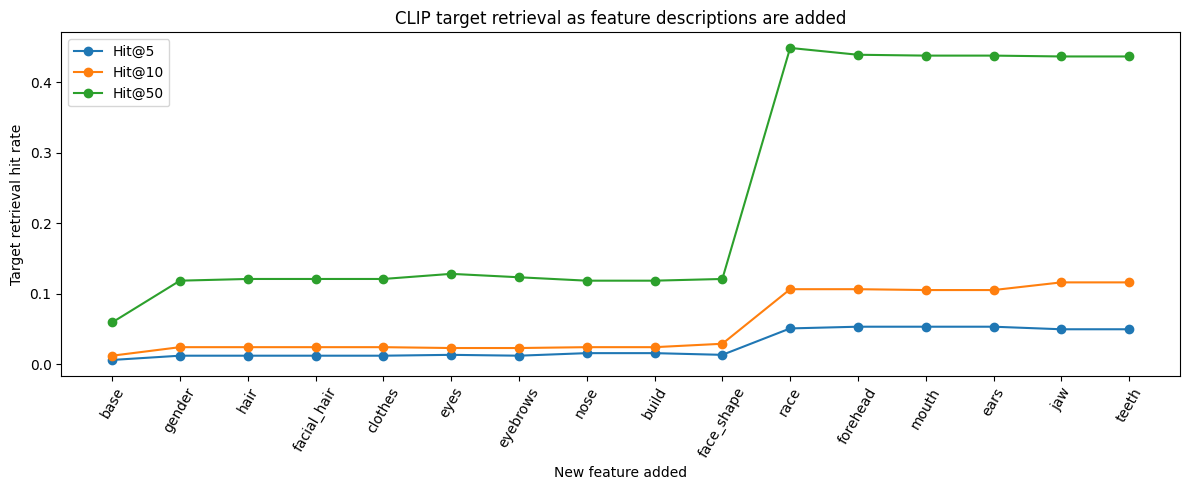

In [12]:
import matplotlib.pyplot as plt

plot_df = stage_summary.copy()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["added_feature"], plot_df["hit_rate_top_5"], marker="o", label="Hit@5")
ax.plot(plot_df["added_feature"], plot_df["hit_rate_top_10"], marker="o", label="Hit@10")
ax.plot(plot_df["added_feature"], plot_df["hit_rate_top_50"], marker="o", label="Hit@50")
ax.set_ylabel("Target retrieval hit rate")
ax.set_xlabel("New feature added")
ax.set_title("CLIP target retrieval as feature descriptions are added")
ax.tick_params(axis="x", rotation=60)
ax.legend()
fig.tight_layout()

## 8. Feature-Consistency Accuracy

Target retrieval asks whether the exact CFD identity is retrieved. Feature consistency asks a different question: when a feature such as `gender`, `nose`, or `mouth` is added to the text, do retrieved faces share the same feature label as the target?

This is a more direct diagnostic of the image-text shared semantic space for each feature category.

In [13]:
label_records = []
for _, row in manifest.iterrows():
    record = {"target_id": row["target_id"], "image_id": row["image_id"]}
    for feature, _ in FEATURE_ORDER:
        phrases = feature_phrases(row, feature)
        record[f"label_{feature}"] = " | ".join(p.label for p in phrases) if phrases else np.nan
    label_records.append(record)

label_table = pd.DataFrame(label_records)
label_by_target = label_table.drop_duplicates("target_id").set_index("target_id")
label_table.head()

,target_id,image_id,label_gender,label_hair,label_facial_hair,label_clothes,label_eyes,label_eyebrows,label_nose,label_build,label_face_shape,label_race,label_forehead,label_mouth,label_ears,label_jaw,label_teeth
0,AF-200,CFD-AF-200-228-N,female,NaN,NaN,NaN,large eyes | round eyes,NaN,medium-width nose | medium-length nose,NaN,round face | medium facial width,asian,low forehead,full lips,NaN,short chin,NaN
1,AF-201,CFD-AF-201-060-N,female,NaN,NaN,NaN,small eyes | medium eye shape,NaN,medium-width nose | medium-length nose,NaN,round face | wide facial width,asian,medium forehead,full lips,NaN,short chin,NaN
2,AF-202,CFD-AF-202-122-N,female,NaN,NaN,NaN,medium-sized eyes | medium eye shape,NaN,broad nose | long nose,NaN,medium face shape | medium facial width,asian,medium forehead,medium lips,NaN,medium chin,NaN
3,AF-203,CFD-AF-203-077-N,female,NaN,NaN,NaN,large eyes | round eyes,NaN,medium-width nose | medium-length nose,NaN,round face | medium facial width,asian,low forehead,full lips,NaN,short chin,NaN
4,AF-204,CFD-AF-204-067-N,female,NaN,NaN,NaN,large eyes | round eyes,NaN,broad nose | long nose,NaN,round face | wide facial width,asian,medium forehead,thin lips,NaN,medium chin,NaN


In [14]:
consistency_rows = []
for spec in stages[1:]:
    feature = spec["added_feature"]
    label_col = f"label_{feature}"

    stage_retrieval = retrieval_all.loc[retrieval_all["stage"] == spec["stage"]].copy()
    stage_queries = ladder_queries.loc[
        ladder_queries["stage"] == spec["stage"],
        ["query_id", "target_id"],
    ].copy()
    stage_queries = stage_queries.rename(columns={"target_id": "query_target_id"})

    if label_col in ladder_queries.columns:
        stage_queries["query_label"] = ladder_queries.loc[
            ladder_queries["stage"] == spec["stage"], label_col
        ].to_numpy()
    else:
        stage_queries["query_label"] = np.nan

    query_label_coverage = float(stage_queries["query_label"].notna().mean() * 100)
    if stage_retrieval.empty or label_col not in label_by_target.columns:
        for k in [1, 5, 10, 50]:
            consistency_rows.append({
                "stage": spec["stage"],
                "feature": feature,
                "top_k": k,
                "n_comparable_pairs": 0,
                "feature_consistency": np.nan,
                "query_label_coverage_percent": query_label_coverage,
            })
        continue

    tmp = stage_retrieval.merge(stage_queries, left_on="query_query_id", right_on="query_id", how="left")
    tmp["candidate_label"] = tmp["target_id"].map(label_by_target[label_col])
    tmp["label_match"] = tmp["query_label"].notna() & tmp["candidate_label"].notna() & (tmp["query_label"] == tmp["candidate_label"])
    tmp["label_comparable"] = tmp["query_label"].notna() & tmp["candidate_label"].notna()

    for k in [1, 5, 10, 50]:
        subset = tmp.loc[(tmp["rank"] <= k) & tmp["label_comparable"]]
        consistency_rows.append({
            "stage": spec["stage"],
            "feature": feature,
            "top_k": k,
            "n_comparable_pairs": int(len(subset)),
            "feature_consistency": float(subset["label_match"].mean()) if len(subset) else np.nan,
            "query_label_coverage_percent": query_label_coverage,
        })

feature_consistency = pd.DataFrame(consistency_rows)
feature_consistency.to_csv(FEATURE_OUT / "feature_consistency_summary.csv", index=False)
feature_consistency.head(20)

,stage,feature,top_k,n_comparable_pairs,feature_consistency,query_label_coverage_percent
0,01_add_gender,gender,1,826,1.000000,99.879081
1,01_add_gender,gender,5,4130,1.000000,99.879081
2,01_add_gender,gender,10,8260,1.000000,99.879081
3,01_add_gender,gender,50,41300,1.000000,99.879081
4,02_add_hair,hair,1,0,NaN,10.640871
5,02_add_hair,hair,5,0,NaN,10.640871
6,02_add_hair,hair,10,0,NaN,10.640871
7,02_add_hair,hair,50,42,1.000000,10.640871
8,03_add_facial_hair,facial_hair,1,0,NaN,0.000000
9,03_add_facial_hair,facial_hair,5,0,NaN,0.000000


In [15]:
feature_consistency.loc[feature_consistency["top_k"].isin([1, 5, 10])].pivot_table(
    index="feature",
    columns="top_k",
    values="feature_consistency",
    aggfunc="first",
).sort_values(1, ascending=False)

top_k,1,5,10
feature,,,
gender,1.000000,1.000000,1.000000
race,0.700969,0.745278,0.751332
mouth,0.426150,0.449395,0.455811
jaw,0.414044,0.414770,0.418039
forehead,0.400726,0.393220,0.403632
eyebrows,0.255814,0.442155,0.480423
eyes,0.168281,0.217433,0.218160
face_shape,0.167070,0.155932,0.157264
nose,0.130751,0.126392,0.118281


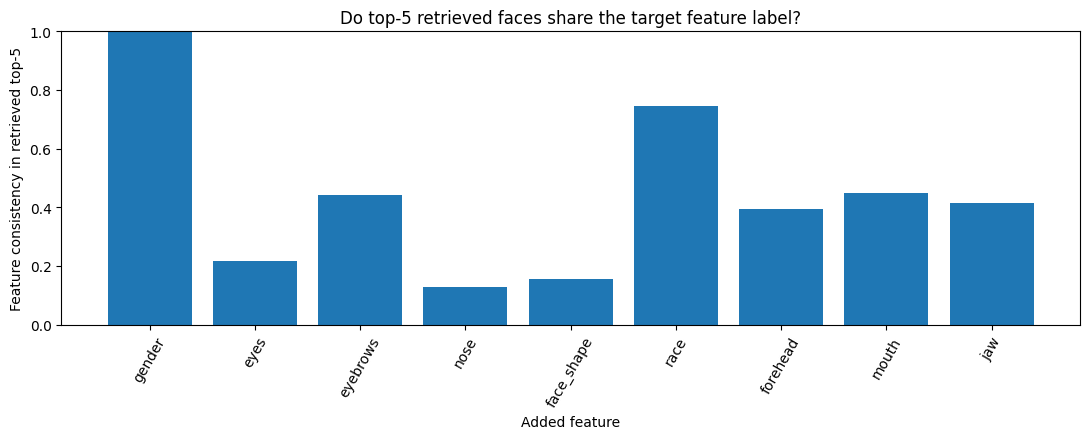

In [16]:
fig, ax = plt.subplots(figsize=(11, 4.5))
plot_consistency = feature_consistency.loc[feature_consistency["top_k"] == 5].dropna(subset=["feature_consistency"])
ax.bar(plot_consistency["feature"], plot_consistency["feature_consistency"])
ax.set_ylim(0, 1)
ax.set_ylabel("Feature consistency in retrieved top-5")
ax.set_xlabel("Added feature")
ax.set_title("Do top-5 retrieved faces share the target feature label?")
ax.tick_params(axis="x", rotation=60)
fig.tight_layout()

## 9. Inspect One Query And Its Retrieved Lineup

Stage: 15_add_teeth
Target: AF-200
Description: A neutral frontal face photograph of a female asian person with large eyes, round eyes, medium-width nose, medium-length nose, round face, medium facial width, low forehead, full lips, short chin.


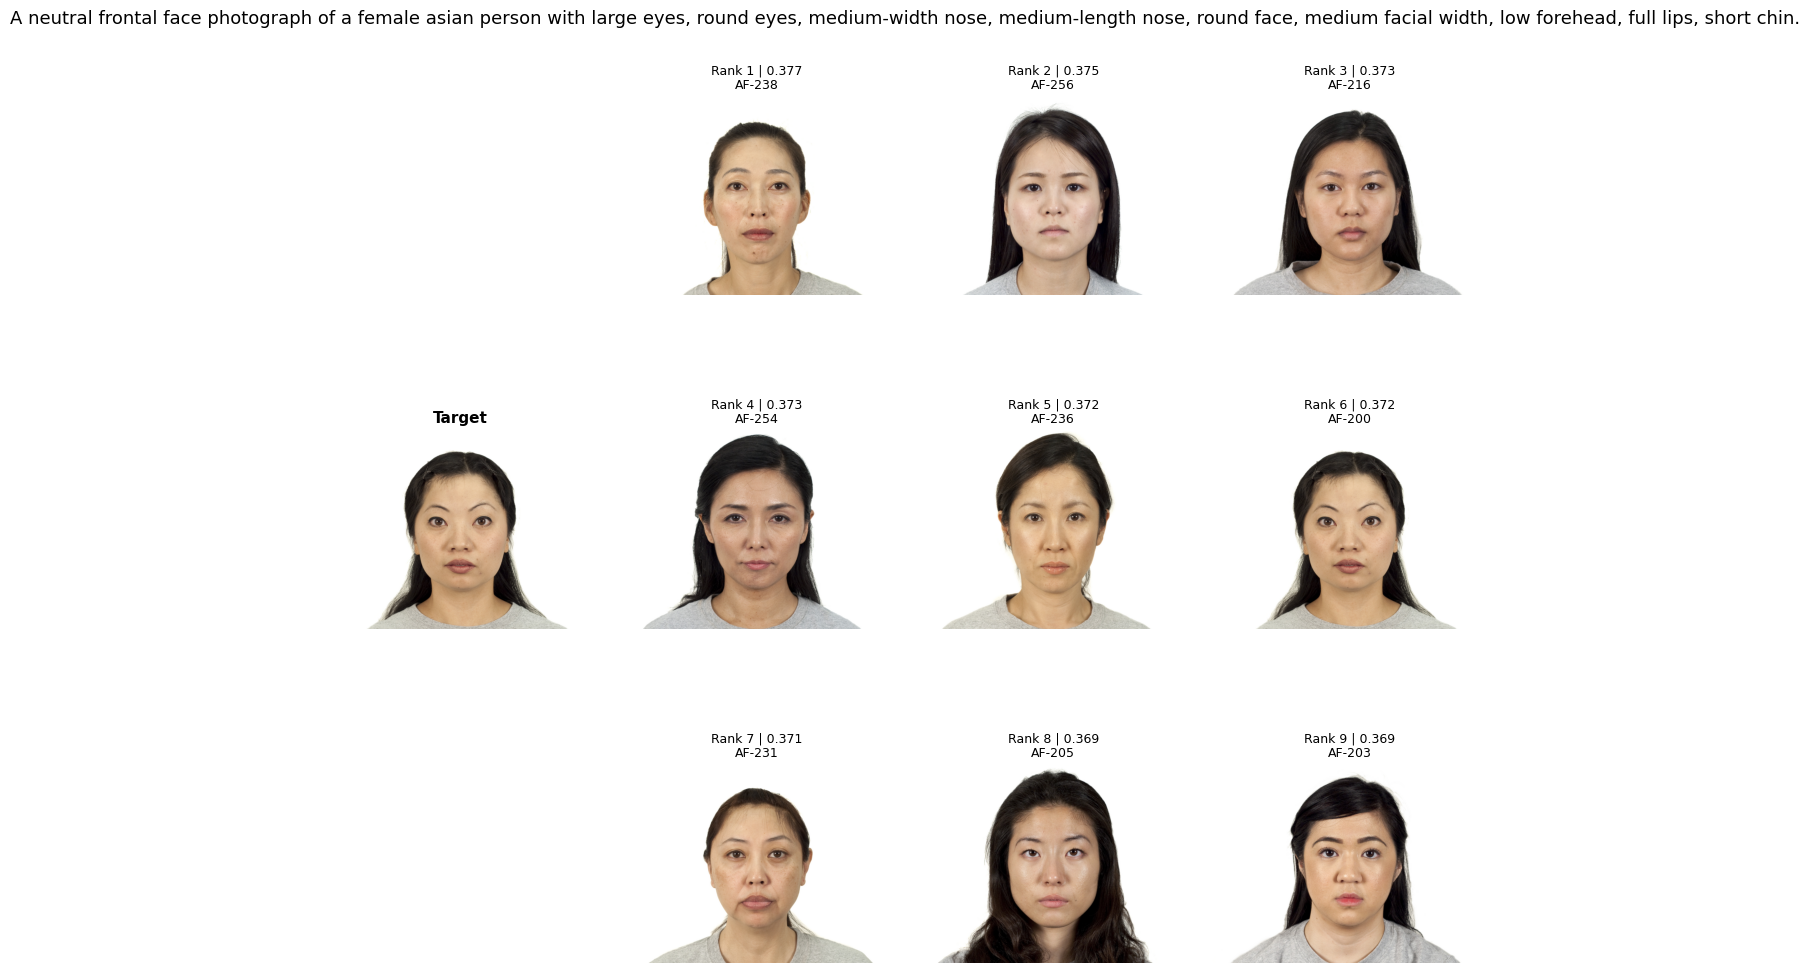

In [17]:
TARGET_ID = manifest.iloc[0]["target_id"]
STAGE_TO_SHOW = stage_summary.iloc[-1]["stage"]

one_query = ladder_queries.loc[(ladder_queries["stage"] == STAGE_TO_SHOW) & (ladder_queries["target_id"] == TARGET_ID)].iloc[0]
one_results = retrieval_all.loc[(retrieval_all["stage"] == STAGE_TO_SHOW) & (retrieval_all["query_query_id"] == TARGET_ID)].copy()

print("Stage:", STAGE_TO_SHOW)
print("Target:", TARGET_ID)
print("Description:", one_query["description"])

fig = show_clip_lineup(
    one_results,
    target_image_path=one_query["image_path"],
    root=ROOT,
    top_k=9,
    cols=3,
    target_position="left",
    suptitle=one_query["description"],
)

## 10. Output Files

This notebook writes the following files:

- `feature_metadata_support.csv`: which feature categories are supported by CFD metadata
- `feature_ladder_queries.csv`: all generated prompts for every ladder stage
- `feature_ladder_stage_summary.csv`: target retrieval hit rates per prompt stage
- `feature_ladder_per_query_metrics.csv`: per-target retrieval metrics per stage
- `feature_ladder_retrieval_results.csv`: top-k retrieval rows for all stages
- `feature_consistency_summary.csv`: feature-label consistency in retrieved results
